## 目标与运行方法

下载完整 `.ipynb`，在 VibeIt Studio 文件浏览器中使用 **+ → Import from Files** 导入并打开。按从上到下的顺序运行代码单元；阅读模式中的图表是已保存的真实运行输出。重新运行会从内嵌数据计算结果。

本课适合具备 Python 基础的本科生。先阅读每一步的方法与图注，再修改参数。AI 练习为可选部分，不需要 AI 账号即可完成核心课程。数据写在 notebook metadata 中，不需要另下载数据文件。请保持 notebook 已保存到当前工作文件夹。

学习任务是理解本课的研究问题、执行透明的计算、校验结果，并说明结论的边界。

## 环境与参数

In [1]:
from pathlib import Path
import base64, gzip, hashlib, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import py3Dmol
from scipy.spatial.distance import cdist
from IPython.display import display as _display
def display(value):
    if isinstance(value,pd.DataFrame):
        table=value.to_html(max_rows=12,escape=True)
        style="<style>.vibeit-readable-table{max-width:100%;overflow-x:auto}.vibeit-readable-table table{width:max-content;max-width:none;border-collapse:collapse}.vibeit-readable-table td,.vibeit-readable-table th{white-space:nowrap!important;word-break:normal!important;overflow-wrap:normal!important}</style>"
        return _display(HTML(style+'<div class="vibeit-readable-table">'+table+'</div>'))
    return _display(value)
RECIPE_ID='07-imatinib-pocket'
OUTPUT_DIR=Path.cwd()/"results"/RECIPE_ID
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,"axes.spines.right":False,
                      "axes.prop_cycle":plt.cycler(color=["#18785f","#416aa6","#bc6541","#9974a5"])})
print("Python:",platform.python_version(),"; NumPy:",np.__version__,"; Pandas:",pd.__version__)
print("Working folder:",Path.cwd())
print("Core data mode: embedded snapshot; no network requests")


Python: 3.10.8 ; NumPy: 1.26.4 ; Pandas: 2.3.3
Working folder: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads
Core data mode: embedded snapshot; no network requests


### 读取内嵌快照

下面的加载函数按课程 ID 与 SHA-256 在当前文件夹定位本 notebook，解压后再次校验。文件改名不影响匹配。若找不到数据，确认当前工作目录与文件位置；不要用编造的数据替换它。metadata 随 `.ipynb` 保存及导出，复制代码到单独 `.py` 不会自动复制数据。

In [2]:
def load_snapshot(recipe_id, expected_sha256, snapshot_key):
    """Read embedded data from this notebook, including a renamed copy."""
    for path in sorted(Path.cwd().glob("*.ipynb")):
        try:
            notebook = json.loads(path.read_text(encoding="utf-8"))
            metadata = notebook.get("metadata", {}).get("vibeit_cookbook", {})
            blob = metadata.get("snapshots", {}).get(snapshot_key)
            if metadata.get("recipe_id") != recipe_id or not blob:
                continue
            if blob.get("sha256") != expected_sha256:
                continue
            raw = gzip.decompress(base64.b64decode(blob["gzip_base64"], validate=True))
            if hashlib.sha256(raw).hexdigest() != expected_sha256:
                raise ValueError("Embedded snapshot checksum mismatch: " + snapshot_key)
            return json.loads(raw)
        except (OSError, json.JSONDecodeError):
            continue
    raise FileNotFoundError(
        "Save/open the complete .ipynb in the active working folder. "
        "The embedded snapshot could not be located for " + recipe_id)

SNAPSHOT_HASHES={'imatinib': '5c917b32818fda4715c7887577a22d275c25e7a80f9ebf0e6b55e923f2c1f187'}
def snapshot(key):
    return load_snapshot(RECIPE_ID,SNAPSHOT_HASHES[key],key)
print("Embedded snapshots:",list(SNAPSHOT_HASHES))


Embedded snapshots: ['imatinib']


### 方法函数

本课所需函数的完整代码就在下面。它们只使用已列出的预装包与标准库，运行时不会导入任何 cookbook 辅助模块。先检查输入约束和返回值；如果修改算法，后面的校验也需要继续通过。

In [3]:
def parse_pdb(text):
    """First model; choose highest occupancy altloc, then blank/A/lexical order."""
    rows, first_model, inside = {}, None, True
    for line in text.splitlines():
        record = line[:6].strip()
        if record == "MODEL":
            number = line[10:14].strip()
            if first_model is None:
                first_model = number
            inside = number == first_model
        if record == "ENDMDL" and inside:
            break
        if record not in ("ATOM","HETATM") or not inside:
            continue
        try:
            atom = dict(record=record,serial=int(line[6:11]),atom=line[12:16].strip(),altloc=line[16:17].strip(),
                residue=line[17:20].strip(),chain=line[21:22].strip(),resnum=int(line[22:26]),icode=line[26:27].strip(),
                x=float(line[30:38]),y=float(line[38:46]),z=float(line[46:54]),
                occupancy=float(line[54:60].strip() or 0),bfactor=float(line[60:66].strip() or 0),element=line[76:78].strip())
        except ValueError as exc:
            raise ValueError("Invalid PDB numeric fields") from exc
        key = (record,atom["chain"],atom["resnum"],atom["icode"],atom["residue"],atom["atom"])
        rank = (atom["occupancy"],atom["altloc"]=="",atom["altloc"]=="A")
        old = rows.get(key)
        if old is None or rank > old[0] or (rank == old[0] and atom["altloc"] < old[1]["altloc"]):
            rows[key] = (rank,atom)
    columns = ["record","serial","atom","altloc","residue","chain","resnum","icode","x","y","z","occupancy","bfactor","element"]
    atoms = pd.DataFrame([entry[1] for entry in rows.values()],columns=columns)
    if atoms.empty:
        raise ValueError("No atoms in the first model")
    if not np.isfinite(atoms[["x","y","z","occupancy"]].to_numpy()).all():
        raise ValueError("Nonfinite coordinates or occupancy")
    return atoms

print("Method ready: parse_pdb")


Method ready: parse_pdb


In [4]:
def residue_minimum_distances(left, right):
    """Minimum Euclidean atom distance per residue pair, retaining chain/insertion IDs.

    Caller explicitly selects positive-occupancy heavy atoms. This measures
    geometric proximity, not a hydrogen bond, affinity, buried area or energy.
    At most one residue's atom-distance block is held in memory at a time.
    """
    keys = ['chain', 'resnum', 'icode', 'residue']
    columns = keys + ['atom_count']
    if left.empty or right.empty:
        raise ValueError('Both atom selections must be nonempty')
    if not np.isfinite(left[['x','y','z']].to_numpy()).all() or not np.isfinite(right[['x','y','z']].to_numpy()).all():
        raise ValueError('Coordinates must be finite')
    left = left.reset_index(drop=True)
    right = right.reset_index(drop=True)
    left_groups = list(left.groupby(keys, sort=False).indices.items())
    right_groups = list(right.groupby(keys, sort=False).indices.items())
    left_residues = pd.DataFrame([list(key)+[len(indices)] for key,indices in left_groups], columns=columns)
    right_residues = pd.DataFrame([list(key)+[len(indices)] for key,indices in right_groups], columns=columns)
    right_codes = np.empty(len(right), dtype=int)
    for j, (_, indices) in enumerate(right_groups):
        right_codes[indices] = j
    matrix = np.full((len(left_groups),len(right_groups)), np.inf)
    right_xyz = right[['x','y','z']].to_numpy(dtype=float)
    for i, (_, indices) in enumerate(left_groups):
        block = cdist(left.iloc[indices][['x','y','z']].to_numpy(dtype=float), right_xyz)
        np.minimum.at(matrix[i], right_codes, block.min(axis=0))
    return left_residues, right_residues, matrix

print("Method ready: residue_minimum_distances")


Method ready: residue_minimum_distances


In [5]:
def residue_labels(frame):
    """Display author residue identifiers without discarding insertion codes."""
    return [f'{r.chain}:{r.residue}{int(r.resnum)}{r.icode}' for r in frame.itertuples()]

print("Method ready: residue_labels")


Method ready: residue_labels


In [6]:
def pdb_atom_text(atoms):
    """Serialize an explicitly selected atom table for 3D display, without reorienting it."""
    lines = []
    for r in atoms.itertuples():
        lines.append(f'{r.record:<6}{r.serial:5d} {r.atom:>4} {r.residue:>3} {r.chain:1}{r.resnum:4d}{r.icode:1}   '
                     f'{r.x:8.3f}{r.y:8.3f}{r.z:8.3f}{r.occupancy:6.2f}{r.bfactor:6.2f}          {r.element:>2}  ')
    return '\n'.join(lines) + '\nEND\n'

print("Method ready: pdb_atom_text")


Method ready: pdb_atom_text


### 数据与模型边界

1IEP 是 **鼠源 c-Abl 激酶结构域**的 X 射线结构（2.10 Å），不是完整的人 BCR–ABL 融合蛋白。STI 是伊马替尼。不对称单元含两个激酶副本；本课选作者链 A 及其自身的 STI，不把 A/B 自动解释为二聚体。坐标及 RCSB 身份注释均已冻结。本课分析已观测的复合物，不进行对接，也不重建氢原子、溶剂能量、亲和力或临床反应。

## 分步分析

### 1. 为什么分析这个药物复合物？

先提出课堂问题：**一个小分子，怎样改变大蛋白的工作？** 可以把激酶比作带有 ATP 插槽的机器：伊马替尼占据口袋，并稳定一种非活性构象。这个类比帮助理解位置，但蛋白和药物会运动，水也参与结合。机制解释来自[原始研究](https://pubmed.ncbi.nlm.nih.gov/12154025/)与 [PDB-101](https://pdb101.rcsb.org/motm/283)；我们的计算定位实验姿态和邻近残基。血红素是天然辅因子，伊马替尼是外源抑制剂；两者共享空间分析方法，生物学目的不同。学习目标：核验药物与构建体、旋转结合姿态、定义重原子口袋、检查阈值，以及说明还需要哪些证据才能讨论抑制作用和亲和力。

### 2. 核验蛋白、药物与实验坐标

不要根据熟悉的药名推断物种，先读提交记录。表格将序列长度与已建模 Cα 残基数分开：未解析的原子或残基不能填成零，也不能计算不存在的坐标。选择第一个模型、每个原子占有率最高的替代构象（平局规则见解析函数），排除零占有率与 H/D。逐原子选替代构象是教学近似，不能视作完整联合构象重建。所有坐标来自同一个实验精修坐标系。

In [7]:
KEY = "imatinib"
data = snapshot(KEY)
atoms = parse_pdb(data["pdb"])
heavy = atoms[(atoms.occupancy > 0) & ~atoms.element.isin(["H", "D"])].copy()
assert heavy.serial.is_unique
ca = heavy[(heavy.record == "ATOM") & (heavy.atom == "CA")]
identity = []
for entity in data["entities"]:
    for chain in entity["entity_poly"]["pdbx_strand_id"].split(","):
        identity.append(dict(chain=chain, molecule=entity["rcsb_polymer_entity"]["pdbx_description"],
            deposited_sequence_length=entity["entity_poly"]["rcsb_sample_sequence_length"],
            observed_CA_residues=int((ca.chain == chain).sum())))
display(pd.DataFrame(identity))
print("PDB:", data["pdb_id"], "; resolution (Å):", data["entry"]["rcsb_entry_info"]["resolution_combined"])
print("Revision:", data["entry"]["rcsb_accession_info"]["revision_date"])
print("Selected atom rows:", len(atoms), "; usable heavy atoms:", len(heavy),
      "; zero occupancy:", int((atoms.occupancy == 0).sum()))
print("Non-polymer components:", sorted(atoms.loc[atoms.record == "HETATM", "residue"].unique()))
compound = data["compound"]["chem_comp"]
display(pd.DataFrame([dict(component=compound["id"], formula=compound["formula"],
    formula_weight_Da=compound["formula_weight"], formal_charge=compound["pdbx_formal_charge"])]))
drug = heavy[(heavy.chain == "A") & (heavy.residue == "STI")].copy()
target = heavy[(heavy.chain == "A") & (heavy.record == "ATOM")].copy()
assert len(drug) == 37 and not target.empty
print("Bound drug heavy atoms:", len(drug), "; protein heavy atoms:", len(target))


,chain,molecule,deposited_sequence_length,observed_CA_residues
0,A,PROTO-ONCOGENE TYROSINE-PROTEIN KINASE ABL,293,274
1,B,PROTO-ONCOGENE TYROSINE-PROTEIN KINASE ABL,293,274


PDB: 1IEP ; resolution (Å): [2.1]
Revision: 2023-08-09T00:00:00.000+00:00
Selected atom rows: 4710 ; usable heavy atoms: 4710 ; zero occupancy: 0
Non-polymer components: ['CL', 'HOH', 'STI']


,component,formula,formula_weight_Da,formal_charge
0,STI,C29 H31 N7 O,493.603,0


Bound drug heavy atoms: 37 ; protein heavy atoms: 2229


### 3. 先看药物，再看药物位于蛋白中的位置

第一幅三维图展示**从复合物中提取的药物坐标**：它是实验观察到的结合姿态，不是游离溶液构象，也不是对接预测。第二幅显示绿色 ABL cartoon 与橙色药物 sticks。悬停查看原子名，随后对应距离矩阵。py3Dmol 会为绘图推定部分键连接；这些绘图连接不参与相互作用能计算。选取坐标没有氢，CCD 化学式仍包含氢。

In [8]:
drug_view = py3Dmol.view(width="100%", height=350)
drug_view.addModel(pdb_atom_text(drug), "pdb")
drug_view.setStyle({}, {"stick":{"colorscheme":"orangeCarbon"}})
drug_view.setHoverable({}, True, "function(a,v){if(!a.label)a.label=v.addLabel(a.atom,{position:a,backgroundColor:'white',fontColor:'black'});}",
    "function(a,v){if(a.label){v.removeLabel(a.label);delete a.label;}}")
drug_view.setBackgroundColor("white"); drug_view.zoomTo(); drug_view.zoom(.7)
display(HTML(drug_view._make_html()))
complex_view = py3Dmol.view(width="100%", height=440)
complex_view.addModel(pdb_atom_text(pd.concat([target, drug])), "pdb")
complex_view.setStyle({"chain":"A"}, {"cartoon":{"color":"#18785f"}})
complex_view.setStyle({"resn":"STI"}, {"stick":{"colorscheme":"orangeCarbon"}})
complex_view.setBackgroundColor("white"); complex_view.zoomTo(); complex_view.zoom(.7)
display(HTML(complex_view._make_html()))


### 4. 定义并测量口袋

对残基 r 与药物 L，计算 **d(r,L) = min ||xᵢ − xⱼ||**，遍历选定的重原子对。报告 **≤4.0 Å** 的残基；1 Å = 0.1 nm。这是明确的几何阈值，不是通用成键边界。口袋分析不宜只用 Cα 距离：侧链可能靠近药物，而 Cα 更远。柱形图每个残基一个最短距离，单位 Å，虚线表示阈值。它描述局部环境，不能衡量每个残基的能量贡献。

Pocket residues: 21


,chain,resnum,icode,residue,atom_count,label,min_distance_A
135,A,360,,ILE,8,A:ILE360,2.668500
90,A,315,,THR,7,A:THR315,2.883189
93,A,318,,MET,8,A:MET318,2.899270
156,A,381,,ASP,8,A:ASP381,2.900704
61,A,286,,GLU,9,A:GLU286,2.995906
136,A,361,,HIS,10,A:HIS361,3.161738
74,A,299,,VAL,7,A:VAL299,3.250268
65,A,290,,MET,8,A:MET290,3.308218
92,A,317,,PHE,11,A:PHE317,3.326891
155,A,380,,ALA,5,A:ALA380,3.329238


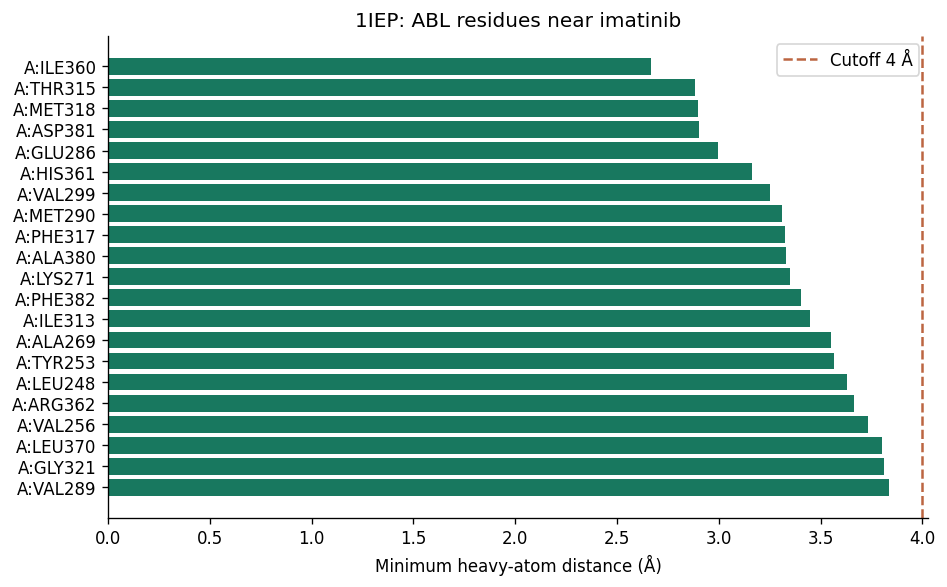

In [9]:
CUTOFF = 4.0
left_residues, right_residues, distances = residue_minimum_distances(drug, target)
target_profile = right_residues.copy()
target_profile["label"] = residue_labels(right_residues)
target_profile["min_distance_A"] = distances.min(axis=0)
pocket = target_profile[target_profile.min_distance_A <= CUTOFF].sort_values("min_distance_A", kind="stable")
print("Pocket residues:", len(pocket))
display(pocket.head(12))
fig, ax = plt.subplots(figsize=(8,5))
if len(pocket):
    ax.barh(pocket.label.iloc[::-1], pocket.min_distance_A.iloc[::-1], color="#18785f")
else:
    ax.text(.5,.5,"No residues within cutoff",ha="center",transform=ax.transAxes)
ax.axvline(CUTOFF, color="#bc6541", linestyle="--", label=f"Cutoff {CUTOFF:g} Å")
ax.set(xlabel="Minimum heavy-atom distance (Å)", title="1IEP: ABL residues near imatinib")
ax.legend(); plt.tight_layout(); plt.show()


### 5. 哪些药物原子靠近哪些残基？

热图保留药物原子名和作者残基编号。每格是一个药物原子到一个口袋残基全部重原子的最短距离。颜色越深距离越近，色阶显示上限为 8 Å。一个残基可以对应多个邻近原子对，原子对数与残基数的分母不同。短的 N/O 距离只能提示候选极性接触；判断氢键还需考虑质子化、供受体性质、角度、缺失的氢与水，不能把所有 N/O 原子都标为氢键供体。

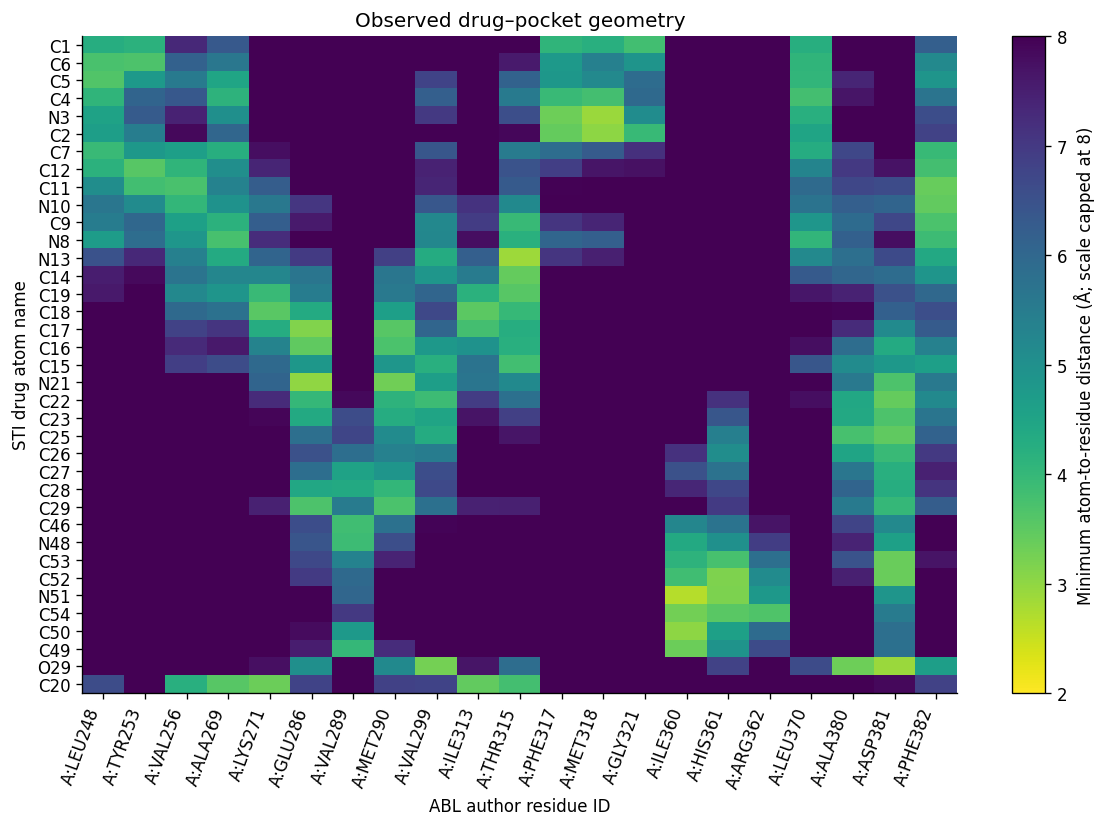

In [10]:
atom_to_target = cdist(drug[["x","y","z"]].to_numpy(), target[["x","y","z"]].to_numpy())
groups = list(target.reset_index(drop=True).groupby(["chain","resnum","icode","residue"], sort=False).indices.values())
atom_residue = np.column_stack([atom_to_target[:,indices].min(axis=1) for indices in groups])
assert np.allclose(atom_residue.min(axis=0), target_profile.min_distance_A)
selected = np.flatnonzero(target_profile.min_distance_A.to_numpy() <= CUTOFF)
fig, ax = plt.subplots(figsize=(10,7))
if len(selected):
    image = ax.imshow(atom_residue[:,selected], aspect="auto", cmap="viridis_r", vmin=2, vmax=8)
    ax.set(xticks=range(len(selected)), xticklabels=target_profile.label.iloc[selected],
           yticks=range(len(drug)), yticklabels=drug.atom)
    plt.setp(ax.get_xticklabels(), rotation=70, ha="right")
    fig.colorbar(image, ax=ax, label="Minimum atom-to-residue distance (Å; scale capped at 8)")
else:
    ax.text(.5,.5,"Empty pocket at this cutoff",ha="center",transform=ax.transAxes)
ax.set(xlabel="ABL author residue ID", ylabel="STI drug atom name", title="Observed drug–pocket geometry")
plt.tight_layout(); plt.show()


### 6. 在空间中标出口袋

绿色点是蛋白 Cα，橙色点是药物重原子，紫色点是通过**重原子**阈值选出口袋残基的 Cα。坐标轴为提交的 Å 坐标，观察方向没有生理含义。新增的局部放大视图以紫色显示所选口袋原子、橙色显示药物，标注最近的四个残基，不改变坐标。序列上相隔很远的残基，可以在折叠后共同围绕同一个药物。

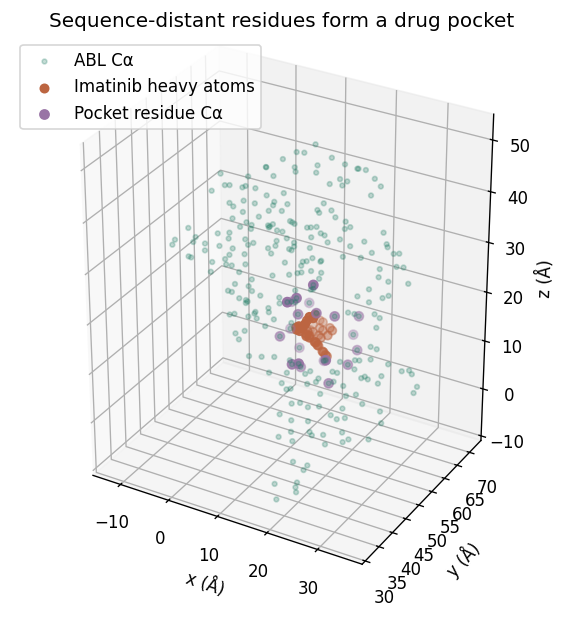

Close-up atoms: 208


In [11]:
target_ca = target[target.atom == "CA"].copy()
target_ca["label"] = residue_labels(target_ca)
pocket_ca = target_ca[target_ca.label.isin(pocket.label)]
fig = plt.figure(figsize=(8,5)); ax = fig.add_subplot(111, projection="3d")
ax.scatter(target_ca.x,target_ca.y,target_ca.z,s=8,c="#18785f",alpha=.25,label="ABL Cα")
ax.scatter(drug.x,drug.y,drug.z,s=25,c="#bc6541",label="Imatinib heavy atoms")
ax.scatter(pocket_ca.x,pocket_ca.y,pocket_ca.z,s=30,c="#9974a5",label="Pocket residue Cα")
ax.set(xlabel="x (Å)",ylabel="y (Å)",zlabel="z (Å)",title="Sequence-distant residues form a drug pocket")
xyz=target[["x","y","z"]].to_numpy(); ax.set_box_aspect(np.ptp(xyz,axis=0))
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()
target_labels = pd.Series(residue_labels(target), index=target.index)
pocket_atoms = target[target_labels.isin(pocket.label)]
pocket_view = py3Dmol.view(width="100%", height=440)
pocket_view.addModel(pdb_atom_text(pd.concat([pocket_atoms, drug])), "pdb")
pocket_view.setStyle({}, {"stick":{"color":"#9974a5","radius":.14}})
pocket_view.setStyle({"resn":"STI"}, {"stick":{"colorscheme":"orangeCarbon","radius":.2}})
for row in pocket.iloc[:4].itertuples():
    position = pocket_ca[pocket_ca.label == row.label]
    if len(position):
        r = position.iloc[0]
        pocket_view.addLabel(row.label, {"position":{"x":float(r.x),"y":float(r.y),"z":float(r.z)},
            "backgroundColor":"white","fontColor":"black","fontSize":12,"backgroundOpacity":.8})
pocket_view.setBackgroundColor("white"); pocket_view.zoomTo(); pocket_view.zoom(.7)
display(HTML(pocket_view._make_html()))
print("Close-up atoms:", len(pocket_atoms)+len(drug))


### 7. 检查阈值敏感性与结果解释

固定实验姿态下，增加阈值只能增加所选残基；曲线表示定义如何变化，**不是药物剂量反应曲线**。问学生：能得出什么结论？“在当前选择规则下，实验中的伊马替尼姿态被这些 ABL 残基包围。”还需要什么？亲和力需结合实验，抑制作用需激酶实验，生物效应需细胞与选择性证据。单个结构不能证明效力、耐药或患者获益。这里保留作者编号；讲临床突变前必须建立物种与异构体的序列编号映射。

,cutoff_A,target_residues
0,0.01,0
1,3.00,5
2,3.50,13
3,4.00,21
4,4.50,25
5,5.00,28
6,6.00,32


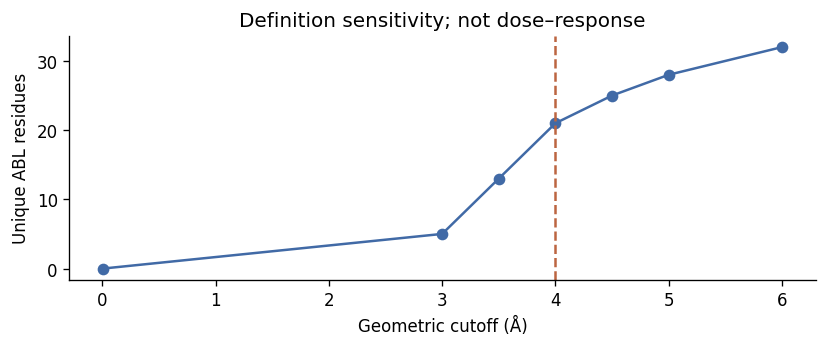

In [12]:
threshold_table = pd.DataFrame([dict(cutoff_A=t,
    target_residues=int((target_profile.min_distance_A <= t).sum())) for t in [0.01,3.,3.5,4.,4.5,5.,6.]])
assert np.all(np.diff(threshold_table.target_residues) >= 0)
display(threshold_table)
fig,ax=plt.subplots(figsize=(7,3))
ax.plot(threshold_table.cutoff_A,threshold_table.target_residues,"o-",color="#416aa6")
ax.axvline(CUTOFF,ls="--",color="#bc6541")
ax.set(xlabel="Geometric cutoff (Å)",ylabel="Unique ABL residues",title="Definition sensitivity; not dose–response")
plt.tight_layout(); plt.show()


### 8. 校验并导出

独立重算最近的原子对，再整体平移复合物：距离应一致。导出所选复合物、完整残基距离、阈值曲线与摘要；CSV 距离单位为 Å。错误选择会报错；有效的零接触结果保持为空，不补入虚构接触。保留冻结快照并记录参数修改。

In [13]:
# Independent atom-pair calculation for the closest residue pair.
i, j = np.unravel_index(np.argmin(distances), distances.shape)
def residue_atoms(frame, row):
    return frame[(frame.chain == row.chain) & (frame.resnum == row.resnum) &
                 (frame.icode == row.icode) & (frame.residue == row.residue)]
left_test = residue_atoms(drug, left_residues.iloc[i])
right_test = residue_atoms(target, right_residues.iloc[j])
manual_minimum = min(float(np.linalg.norm(a-b))
    for a in left_test[["x","y","z"]].to_numpy() for b in right_test[["x","y","z"]].to_numpy())
assert np.isclose(manual_minimum, distances[i,j], atol=1e-12)
# A common rigid translation cannot change any distance.
shifted_drug = drug.copy(); shifted_target = target.copy()
shifted_drug[["x","y","z"]] += np.array([10., -7., 3.])
shifted_target[["x","y","z"]] += np.array([10., -7., 3.])
_, _, shifted_distances = residue_minimum_distances(shifted_drug, shifted_target)
assert np.allclose(distances, shifted_distances, atol=1e-12)
# Empty selections fail explicitly; a zero-contact threshold is a valid result.
try:
    residue_minimum_distances(drug.iloc[:0], target)
except ValueError:
    print("Empty selection: reported correctly")
else:
    raise AssertionError("Empty selection was accepted")
assert not (distances <= 0.01).any()
assert np.isfinite(distances).all() and (distances >= 0).all()
print("PASS: independent atom minimum, rigid translation, finite distances, empty selections and empty contacts")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
target_profile.to_csv(OUTPUT_DIR / "target-residue-distances.csv", index=False)
threshold_table.to_csv(OUTPUT_DIR / "threshold-sensitivity.csv", index=False)
pd.DataFrame(distances, index=residue_labels(left_residues), columns=residue_labels(right_residues)).to_csv(
    OUTPUT_DIR / "residue-minimum-distances.csv")
(OUTPUT_DIR / "selected-complex.pdb").write_text(pdb_atom_text(pd.concat([target, drug])), encoding="ascii")
summary = dict(pdb_id=data["pdb_id"], cutoff_angstrom=CUTOFF,
    atom_selection="positive occupancy heavy atoms; parser selects one altloc per atom",
    target_chains=sorted(target.chain.unique()), drug_chains=sorted(drug.chain.unique()),
    target_residues_within_cutoff=int((target_profile.min_distance_A <= CUTOFF).sum()),
    contacting_residue_pairs=int((distances <= CUTOFF).sum()),
    method="minimum atom distance, not affinity, interaction energy or buried surface area")
(OUTPUT_DIR / "analysis-summary.json").write_text(json.dumps(summary, indent=2)+"\n")
print("Exported:", sorted(p.name for p in OUTPUT_DIR.iterdir()))


Empty selection: reported correctly
PASS: independent atom minimum, rigid translation, finite distances, empty selections and empty contacts


Exported: ['analysis-summary.json', 'residue-minimum-distances.csv', 'selected-complex.pdb', 'target-residue-distances.csv', 'threshold-sensitivity.csv']


## 自主练习与参考答案

1. 比较 3.5、4.0、5.0 Å 的口袋。为什么药物姿态不变，成员仍会改变？
2. 只使用 Cα，重算距离药物最近的口袋残基。为什么它可能不再满足重原子口袋定义？

**参考解释。** 增加阈值改变几何选择，不改变化学。Cα 是骨架参考点，侧链原子可以更靠近药物。更多接触不能推出更高亲和力。

先保留当前 notebook 副本，再修改参数。把新图与原图一起比较，并记录改变了哪些输入、哪些计算和哪些结论。

## 可选的 AI 编程练习

在 VibeIt 的 Coding Agent 中打开当前 notebook，先让助手阅读相关单元。核心课程不依赖 AI 服务；服务可用性与账号设置以应用帮助中心为准。

**提示词 1**

> 只用本课列出的 NumPy/Pandas/SciPy/Matplotlib/py3Dmol 与标准库，增加 3.5/4/5 Å 的 CUTOFF 控制，并在三维复合物中给口袋原子重新上色。保留数据与作者编号，不进行对接、不报告结合能。

**提示词 2**

> 利用所选实验坐标，给每个药物 N/O 原子列出最近的蛋白原子，称为候选极性邻近关系，不叫已证实氢键。保留原子名、残基编号与 Å 单位；只用已列包。

**人工验收。** 手动运行全部受影响单元。口袋数量须单调不减，三维原子选择须与表格一致；用 np.linalg.norm 复算一项 N/O 距离，保留原有快照与平移校验。

检查修改后的源代码，再手动运行受影响单元及后续校验。要求助手解释修改的目的、使用的包和数据来源，并用实际输出核对解释。

## 可选联网扩展

默认关闭下面的联网操作。它只显示数据库版本及快照来源，不会替换核心数据。若要重新获取数据，应另存一个实验版本并记录新的 URL、数据库版本、获取日期与 SHA-256；新版结果需要重新执行和核验。

In [14]:
RUN_ONLINE_UPDATE=False
if RUN_ONLINE_UPDATE:
    import requests
    try:
        response=requests.get('https://data.rcsb.org/rest/v1/core/entry/1IEP',timeout=20)
        response.raise_for_status()
        print("Source:",response.url)
        print(response.text[:700])
    except requests.RequestException as error:
        print("Online extension unavailable:",type(error).__name__,str(error)[:160])
else:
    print("Online extension skipped; embedded core data unchanged")


Online extension skipped; embedded core data unchanged


## 来源、快照与下一步

- [Drug complex 1IEP coordinates](https://files.rcsb.org/download/1IEP.pdb) — CC0 1.0 (wwPDB data); credit depositors and primary publication; retrieved 2026-10-10. SHA-256 `577386b4b8bc58a570facba0c8a843386842caef5ed7b60106c685d0f68d4218`.
  Preserve complete original PDB; first-model, occupancy and chain selections are visible student code. No docking or coordinate registration.

- [Drug complex 1IEP entry metadata](https://data.rcsb.org/rest/v1/core/entry/1IEP) — CC0 1.0 (wwPDB data); credit depositors and primary publication; retrieved 2026-10-10. SHA-256 `09499268eccba586c0443425240eccc171748fd24bc964c448e792c2ad96e4c2`.
  Preserve experiment, revision and primary citation metadata.

- [Drug complex 1IEP polymer entity 1](https://data.rcsb.org/rest/v1/core/polymer_entity/1IEP/1) — CC0 1.0 (wwPDB data); credit depositors and primary publication; retrieved 2026-10-10. SHA-256 `010c30720f818eb5cd6d32507bacff456173ce04b1f5653a5e4dcbda9b998f8a`.
  Preserve entity identity, source species, sequences and author chain IDs; do not infer a chain role from color.

- [Drug complex STI chemical component](https://data.rcsb.org/rest/v1/core/chemcomp/STI) — CC0 1.0 (wwPDB data); credit depositors and primary publication; retrieved 2026-10-10. SHA-256 `071661c3f0296df1a405b9157d5190d7cc0d50297c13b97a3ce2f7056007cc59`.
  Preserve chemical identity, formula, descriptors and reported atom counts. Atom names and bound coordinates come from 1IEP, not ideal CCD coordinates.


**下一步。** 在保留本课的数据检查、参数记录和结果校验之后，将相同方法用于自己的公开或已获授权数据。记录研究设计与方法限制，不把示例结果当成新实验的验证。完整数据许可与生成说明见 cookbook 网页。